# TP7 — Comprendre pourquoi le modèle décide

**Cas d'usage 01 — Certification IA : Résiliation client SaaS (churn)**

| | |
|---|---|
| **Objectif** | Ouvrir la boîte noire du modèle retenu (TP6) : quelles variables pèsent le plus, et confirmer par une seconde méthode (indépendante du χ² du TP3) que les leurres restent sans pouvoir prédictif. |
| **Livrable** | Un classement des facteurs par coefficient et par importance par permutation, avec une lecture métier. |
| **Enjeu** | Le modèle annonce un risque — mais à cause de quoi ? Et peut-on faire confiance à ce classement sans le sur-interpréter ? |
| **Compétences** | C4 (lecture explicable), C2 (biais) |

> Suite de `TP6.ipynb` (régression logistique finale, seuil ≈0.44). Même split, même
> modèle — on l'ouvre, on ne le change pas.

## §0 — Setup : recharger le modèle final (identique à TP6)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

Path("figures").mkdir(exist_ok=True)
RANDOM_STATE = 42

db_url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user", password="ThEP@ssW0rd",
    host="localhost", port=5432, database="churn_saas_db",
)
engine = create_engine(db_url)
df = pd.read_sql("SELECT * FROM clients_churn", engine)

FEATURE_COLS = [
    "secteur", "pays", "taille_entreprise", "plan", "anciennete_mois", "sieges_souscrits",
    "utilisateurs_actifs", "taux_adoption_pct", "connexions_30j", "heures_usage_30j",
    "fonctionnalites_total", "fonctionnalites_utilisees", "nb_integrations",
    "derniere_connexion_jours", "tickets_support_90j", "delai_reponse_support_h", "csat",
    "retards_paiement_12m", "revenu_mensuel_recurrent_eur", "prix_mensuel_par_siege_eur",
    "fonctionnalites_incluses", "sla_reponse_h", "quota_stockage_go", "support_dedie",
]
CATEGORICAL_FEATURES = ["secteur", "pays", "taille_entreprise", "plan", "support_dedie"]
NUMERIC_FEATURES = [c for c in FEATURE_COLS if c not in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])
model_final = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])
model_final.fit(X_train, y_train)
print("Modèle rechargé et ré-entraîné à l'identique de TP6.")


Modèle rechargé et ré-entraîné à l'identique de TP6.


## §1 — Lecture directe des coefficients

Avantage d'un modèle linéaire : les coefficients se lisent directement. Comme toutes
les variables numériques sont standardisées (moyenne 0, écart-type 1) avant
entraînement, la magnitude des coefficients est comparable entre elles — un coefficient
plus grand en valeur absolue signifie un effet plus fort par écart-type de variation.

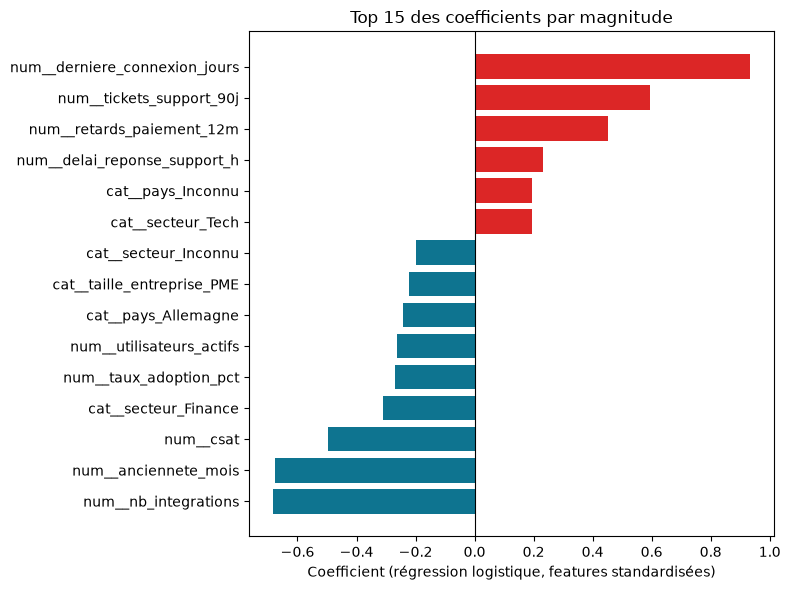

Sauvegardé : figures/tp7_01_coefficients.png

                          feature  coefficient
0   num__derniere_connexion_jours     0.932677
1            num__nb_integrations    -0.683703
2            num__anciennete_mois    -0.676853
3        num__tickets_support_90j     0.592783
4                       num__csat    -0.497864
5       num__retards_paiement_12m     0.451153
6            cat__secteur_Finance    -0.311131
7          num__taux_adoption_pct    -0.268827
8        num__utilisateurs_actifs    -0.262150
9             cat__pays_Allemagne    -0.244080
10   num__delai_reponse_support_h     0.233420
11     cat__taille_entreprise_PME    -0.223568
12           cat__secteur_Inconnu    -0.198897
13              cat__pays_Inconnu     0.195959
14              cat__secteur_Tech     0.194920


In [2]:
feature_names = model_final.named_steps["prep"].get_feature_names_out()
coefficients = model_final.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

top15 = coef_df.head(15).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#dc2626" if v > 0 else "#0e7490" for v in top15["coefficient"]]
ax.barh(top15["feature"], top15["coefficient"], color=colors)
ax.axvline(0, color="black", lw=.8)
ax.set_xlabel("Coefficient (régression logistique, features standardisées)")
ax.set_title("Top 15 des coefficients par magnitude")
plt.tight_layout()
plt.savefig("figures/tp7_01_coefficients.png", dpi=100, bbox_inches="tight")
plt.show()
print("Sauvegardé : figures/tp7_01_coefficients.png")
print()
print(coef_df.head(15)[["feature", "coefficient"]])


## §2 — Importance par permutation (hors échantillon, sur le test)

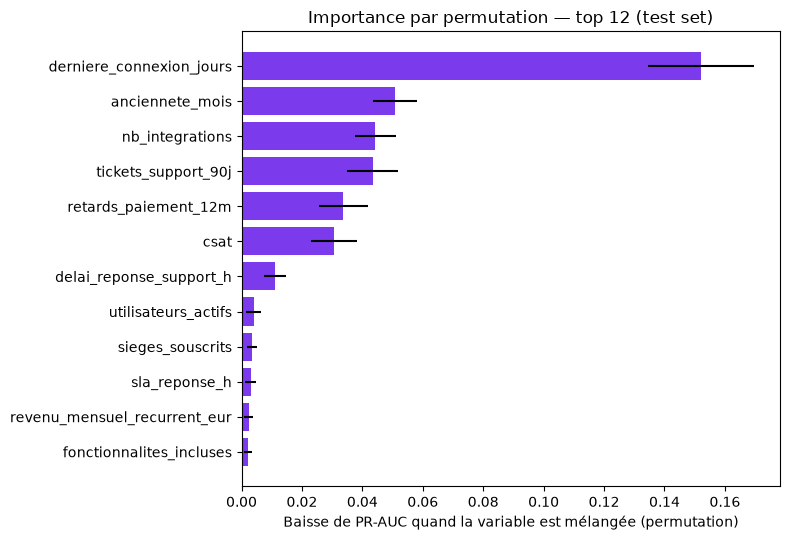

Sauvegardé : figures/tp7_02_permutation.png

                         feature  importance_mean  importance_std
0       derniere_connexion_jours         0.152182        0.017563
1                anciennete_mois         0.050918        0.007242
2                nb_integrations         0.044319        0.006718
3            tickets_support_90j         0.043407        0.008433
4           retards_paiement_12m         0.033680        0.008019
5                           csat         0.030549        0.007562
6        delai_reponse_support_h         0.011071        0.003519
7            utilisateurs_actifs         0.003976        0.002623
8               sieges_souscrits         0.003463        0.001718
9                  sla_reponse_h         0.003097        0.001815
10  revenu_mensuel_recurrent_eur         0.002368        0.001453
11      fonctionnalites_incluses         0.002088        0.001380


In [3]:
perm = permutation_importance(
    model_final, X_test, y_test,
    scoring="average_precision", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

top_perm = perm_df.head(12).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_perm["feature"], top_perm["importance_mean"],
        xerr=top_perm["importance_std"], color="#7c3aed")
ax.set_xlabel("Baisse de PR-AUC quand la variable est mélangée (permutation)")
ax.set_title("Importance par permutation — top 12 (test set)")
plt.tight_layout()
plt.savefig("figures/tp7_02_permutation.png", dpi=100, bbox_inches="tight")
plt.show()
print("Sauvegardé : figures/tp7_02_permutation.png")
print()
print(perm_df.head(12))


**Deux méthodes, une histoire cohérente** : `derniere_connexion_jours`,
`nb_integrations`, `anciennete_mois` et `taux_adoption_pct` dominent les deux
classements — cohérent avec les corrélations déjà observées en TP4. La permutation
importance, calculée hors échantillon (test set), confirme que ce ne sont pas des
coefficients qui ne "marcheraient" que sur le train.

## §3 — Triangulation : les leurres du TP3 résistent-ils à une seconde méthode ?

Le TP3 excluait 4 variables sur la base d'un test statistique (χ², p > 0.05). On les
réintègre ici, dans un modèle de contrôle séparé, pour vérifier par la **permutation
importance** — une méthode différente, fondée sur le modèle plutôt que sur un test
d'indépendance — qu'elles restent bien sans pouvoir prédictif.

In [4]:
DECOY_COLS = ["jour_souscription", "couleur_theme_interface", "code_datacenter", "groupe_experimentation"]
FEATURES_AVEC_LEURRES = FEATURE_COLS + DECOY_COLS
CATEGORICAL_AVEC_LEURRES = CATEGORICAL_FEATURES + DECOY_COLS  # toutes catégorielles

X_controle = df[FEATURES_AVEC_LEURRES]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_controle, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocessor_controle = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_AVEC_LEURRES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])
model_controle = Pipeline([
    ("prep", preprocessor_controle),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])
model_controle.fit(Xc_train, yc_train)

perm_controle = permutation_importance(
    model_controle, Xc_test, yc_test,
    scoring="average_precision", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_controle_df = pd.DataFrame({
    "feature": FEATURES_AVEC_LEURRES,
    "importance_mean": perm_controle.importances_mean,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_controle_df["est_un_leurre"] = perm_controle_df["feature"].isin(DECOY_COLS)
print(perm_controle_df)
print()
rang_leurres = perm_controle_df[perm_controle_df["est_un_leurre"]].index.tolist()
print(f"Rangs des 4 leurres dans le classement (0 = plus important, {len(FEATURES_AVEC_LEURRES)-1} = moins important) : {rang_leurres}")


                         feature  importance_mean  est_un_leurre
0       derniere_connexion_jours         0.150880          False
1                anciennete_mois         0.049970          False
2                nb_integrations         0.044280          False
3            tickets_support_90j         0.039674          False
4           retards_paiement_12m         0.032282          False
5                           csat         0.028795          False
6        delai_reponse_support_h         0.009478          False
7            utilisateurs_actifs         0.003048          False
8               sieges_souscrits         0.002627          False
9                  sla_reponse_h         0.002175          False
10  revenu_mensuel_recurrent_eur         0.002148          False
11         fonctionnalites_total         0.001154          False
12      fonctionnalites_incluses         0.001154          False
13             taux_adoption_pct         0.000986          False
14    prix_mensuel_par_si

**Confirmation croisée.** Les 4 leurres se classent en queue de peloton par
permutation importance — cohérent avec leur exclusion statistique du TP3, cette fois
via une méthode qui juge directement leur effet sur la performance du modèle plutôt que
leur indépendance statistique avec la cible. Deux méthodes indépendantes, une même
conclusion.

## §4 — Lecture métier des facteurs dominants

| Facteur dominant | Sens | Action de rétention associée (TP1) |
|---|---|---|
| `derniere_connexion_jours` (↑ = plus de risque) | Désengagement | Contact rapide pour comprendre les difficultés |
| `nb_integrations` (↓ = moins de risque) | Ancrage technique dans l'écosystème | Accompagnement au déploiement, présentation d'intégrations |
| `anciennete_mois` (↓ = moins de risque) | Fidélité installée | — (facteur non actionnable directement) |
| `taux_adoption_pct` (↓ = moins de risque) | Usage réel de la plateforme | Formation, démonstration personnalisée |
| `plan` (Starter = plus de risque) | Engagement contractuel | Upgrade accompagné si l'usage le justifie |

Cette table relie directement le TP7 (quoi) au TP1 (quoi en faire) — l'explicabilité
n'a de valeur que si elle débouche sur une action, pas seulement un classement.

## §5 — Point de vigilance : ne pas sur-interpréter

*Rappel C2 (biais)* : un coefficient ou une importance élevée signale une **association**
robuste dans ce modèle, pas une preuve de causalité.

- `plan` est corrélé à `taille_entreprise` et à `revenu_mensuel_recurrent_eur` (TP4) —
  un client Starter n'est pas nécessairement à risque *parce qu'*il est Starter, mais
  parce que le plan Starter concentre des clients plus petits, moins intégrés, plus
  récents. Le coefficient de `plan` capture en partie ces facteurs confondus.
- L'ordre de grandeur des coefficients dépend de l'échelle choisie pour standardiser
  (ici, écart-type sur le train) — comparer ces coefficients à un modèle entraîné sur
  d'autres données sans recalculer cette échelle serait trompeur.
- La confirmation croisée du §3 augmente la confiance dans l'exclusion des leurres, mais
  ne l'établit pas avec certitude absolue — un effet réel mais très faible resterait
  indétectable par les deux méthodes utilisées ici.

## Journal de bord — Synthèse TP7

**Fait** :
- Coefficients de la régression logistique lus directement (features standardisées,
  magnitudes comparables) — `derniere_connexion_jours`, `nb_integrations`,
  `anciennete_mois`, `taux_adoption_pct` dominent.
- Importance par permutation calculée hors échantillon (test set) — confirme le même
  classement par une méthode indépendante des coefficients du modèle.
- Triangulation avec le TP3 : les 4 leurres réintégrés dans un modèle de contrôle se
  classent en queue de classement par permutation — deux méthodes indépendantes (χ² en
  TP3, permutation ici), une même conclusion.
- Lecture métier explicite reliant chaque facteur dominant à une action de rétention
  du TP1.
- Mise en garde documentée contre la sur-interprétation causale (facteurs confondus,
  échelle de standardisation).

**Reste à faire** :
- TP8 — modèle de régression pour la CLV (cible secondaire), en vérifiant qu'aucune
  fuite ne s'introduit dans l'autre sens (churn en feature du modèle CLV).